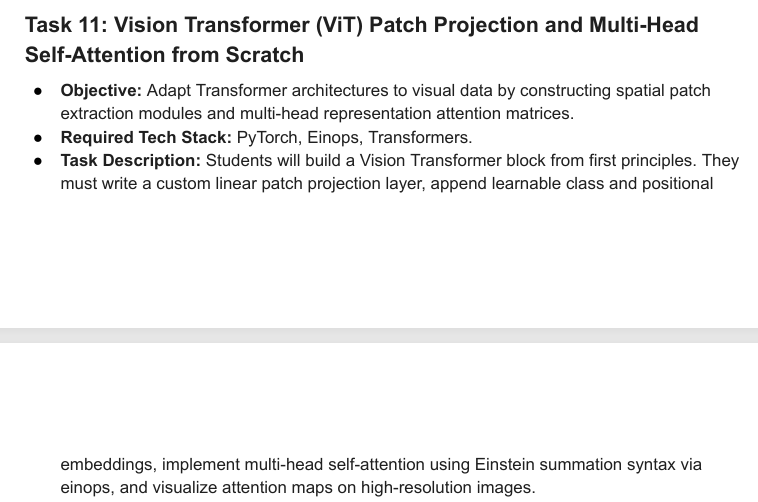

In [2]:
!pip install torch torchvision einops matplotlib

In [3]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from einops import rearrange

In [4]:
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)

Device: cpu


In [5]:
image_size = 224

patch_size = 16

channels = 3

embedding_dim = 128

num_heads = 8

num_classes = 10

num_patches = (
    image_size // patch_size
) ** 2

print("Number of patches:", num_patches)

Number of patches: 196


In [6]:
import torchvision
import torchvision.transforms as transforms

In [7]:
transform = transforms.Compose([
    transforms.Resize(
        (224, 224)
    ),
    transforms.ToTensor()
])

In [8]:
dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

100%|██████████| 170M/170M [28:12<00:00, 101kB/s]


In [9]:
image, label = dataset[0]

print("Image shape:", image.shape)
print("Label:", label)

Image shape: torch.Size([3, 224, 224])
Label: 3


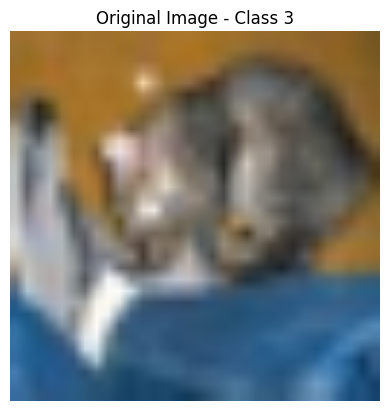

In [10]:
plt.imshow(
    image.permute(1, 2, 0)
)

plt.title(
    f"Original Image - Class {label}"
)

plt.axis("off")

plt.show()

In [11]:
def image_to_patches(
    image,
    patch_size=16
):

    patches = rearrange(
        image,
        'c (h p1) (w p2) -> (h w) (p1 p2 c)',
        p1=patch_size,
        p2=patch_size
    )

    return patches

In [12]:
patches = image_to_patches(
    image,
    patch_size
)

print(
    "Patch shape:",
    patches.shape
)

Patch shape: torch.Size([196, 768])


In [13]:
class PatchProjection(nn.Module):

    def __init__(
        self,
        patch_dimension,
        embedding_dimension
    ):

        super().__init__()

        self.projection = nn.Linear(
            patch_dimension,
            embedding_dimension
        )

    def forward(self, x):

        return self.projection(x)

In [14]:
patch_dimension = (
    patch_size
    *
    patch_size
    *
    channels
)

projection = PatchProjection(
    patch_dimension,
    embedding_dim
)

embedded_patches = projection(
    patches
)

print(
    "Embedded patches:",
    embedded_patches.shape
)

Embedded patches: torch.Size([196, 128])


In [15]:
class ClassToken(nn.Module):

    def __init__(
        self,
        embedding_dim
    ):

        super().__init__()

        self.cls_token = nn.Parameter(
            torch.randn(
                1,
                1,
                embedding_dim
            )
        )

    def forward(self, x):

        batch_size = x.shape[0]

        cls = self.cls_token.expand(
            batch_size,
            -1,
            -1
        )

        return torch.cat(
            [cls, x],
            dim=1
        )

In [16]:
class PositionalEmbedding(
    nn.Module
):

    def __init__(
        self,
        num_tokens,
        embedding_dim
    ):

        super().__init__()

        self.position = nn.Parameter(
            torch.randn(
                1,
                num_tokens,
                embedding_dim
            )
        )

    def forward(self, x):

        return x + self.position

In [17]:
class MultiHeadAttention(
    nn.Module
):

    def __init__(
        self,
        embedding_dim,
        num_heads
    ):

        super().__init__()

        self.num_heads = num_heads

        self.head_dim = (
            embedding_dim // num_heads
        )

        self.scale = (
            self.head_dim ** -0.5
        )

        self.qkv = nn.Linear(
            embedding_dim,
            embedding_dim * 3
        )

        self.output = nn.Linear(
            embedding_dim,
            embedding_dim
        )

    def forward(self, x):

        qkv = self.qkv(x)

        q, k, v = qkv.chunk(
            3,
            dim=-1
        )

        q = rearrange(
            q,
            'b n (h d) -> b h n d',
            h=self.num_heads
        )

        k = rearrange(
            k,
            'b n (h d) -> b h n d',
            h=self.num_heads
        )

        v = rearrange(
            v,
            'b n (h d) -> b h n d',
            h=self.num_heads
        )

        # Attention scores
        attention = torch.einsum(
            'bhid,bhjd->bhij',
            q,
            k
        )

        attention = (
            attention
            *
            self.scale
        )

        attention = torch.softmax(
            attention,
            dim=-1
        )

        # Weighted values
        output = torch.einsum(
            'bhij,bhjd->bhid',
            attention,
            v
        )

        output = rearrange(
            output,
            'b h n d -> b n (h d)'
        )

        output = self.output(
            output
        )

        return output, attention

In [18]:
x = embedded_patches.unsqueeze(0)

attention_layer = MultiHeadAttention(
    embedding_dim,
    num_heads
)

attention_output, attention_map = (
    attention_layer(x)
)

print(
    "Attention output:",
    attention_output.shape
)

print(
    "Attention map:",
    attention_map.shape
)

Attention output: torch.Size([1, 196, 128])
Attention map: torch.Size([1, 8, 196, 196])


In [19]:
class ViT(nn.Module):

    def __init__(
        self,
        image_size=224,
        patch_size=16,
        channels=3,
        embedding_dim=128,
        num_heads=8,
        num_classes=10
    ):

        super().__init__()

        self.patch_size = patch_size

        self.num_patches = (
            image_size // patch_size
        ) ** 2

        patch_dimension = (
            patch_size
            *
            patch_size
            *
            channels
        )

        # Patch projection
        self.projection = nn.Linear(
            patch_dimension,
            embedding_dim
        )

        # CLS token
        self.cls_token = nn.Parameter(
            torch.randn(
                1,
                1,
                embedding_dim
            )
        )

        # Positional embedding
        self.position = nn.Parameter(
            torch.randn(
                1,
                self.num_patches + 1,
                embedding_dim
            )
        )

        # Attention
        self.attention = (
            MultiHeadAttention(
                embedding_dim,
                num_heads
            )
        )

        # Normalization
        self.norm1 = nn.LayerNorm(
            embedding_dim
        )

        self.norm2 = nn.LayerNorm(
            embedding_dim
        )

        # MLP
        self.mlp = nn.Sequential(

            nn.Linear(
                embedding_dim,
                embedding_dim * 4
            ),

            nn.GELU(),

            nn.Linear(
                embedding_dim * 4,
                embedding_dim
            )
        )

        # Classifier
        self.classifier = nn.Linear(
            embedding_dim,
            num_classes
        )

    def forward(self, image):

        x = rearrange(
            image,
            'b c (h p1) (w p2) -> b (h w) (p1 p2 c)',
            p1=self.patch_size,
            p2=self.patch_size
        )

        x = self.projection(x)

        batch_size = x.shape[0]

        cls = self.cls_token.expand(
            batch_size,
            -1,
            -1
        )

        x = torch.cat(
            [cls, x],
            dim=1
        )

        x = x + self.position

        attention_output, attention = (
            self.attention(x)
        )

        x = self.norm1(
            x + attention_output
        )

        x = self.norm2(
            x + self.mlp(x)
        )

        cls_output = x[:, 0]

        logits = self.classifier(
            cls_output
        )

        return logits, attention

In [20]:
model = ViT().to(device)

print(model)

ViT(
  (projection): Linear(in_features=768, out_features=128, bias=True)
  (attention): MultiHeadAttention(
    (qkv): Linear(in_features=128, out_features=384, bias=True)
    (output): Linear(in_features=128, out_features=128, bias=True)
  )
  (norm1): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
  (mlp): Sequential(
    (0): Linear(in_features=128, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=512, out_features=128, bias=True)
  )
  (classifier): Linear(in_features=128, out_features=10, bias=True)
)


In [21]:
input_image = image.unsqueeze(
    0
).to(device)

print(
    "Input:",
    input_image.shape
)

Input: torch.Size([1, 3, 224, 224])


In [22]:
logits, attention = model(
    input_image
)

print(
    "Output:",
    logits.shape
)

print(
    "Attention:",
    attention.shape
)

Output: torch.Size([1, 10])
Attention: torch.Size([1, 8, 197, 197])


In [23]:
prediction = torch.argmax(
    logits,
    dim=1
)

print(
    "Predicted class:",
    prediction.item()
)

print(
    "Actual class:",
    label
)

Predicted class: 4
Actual class: 3


In [24]:
criterion = nn.CrossEntropyLoss()

In [25]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

In [26]:
train_subset = torch.utils.data.Subset(
    dataset,
    range(1000)
)

train_loader = torch.utils.data.DataLoader(
    train_subset,
    batch_size=32,
    shuffle=True
)

In [27]:
model.train()

loss_history = []

for epoch in range(5):

    total_loss = 0

    for images, labels in train_loader:

        images = images.to(device)

        labels = labels.to(device)

        logits, _ = model(images)

        loss = criterion(
            logits,
            labels
        )

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss += loss.item()

    average_loss = (
        total_loss /
        len(train_loader)
    )

    loss_history.append(
        average_loss
    )

    print(
        f"Epoch {epoch+1}/5 "
        f"Loss: {average_loss:.4f}"
    )

Epoch 1/5 Loss: 2.3344
Epoch 2/5 Loss: 2.2203
Epoch 3/5 Loss: 2.1032
Epoch 4/5 Loss: 2.0325
Epoch 5/5 Loss: 1.9250


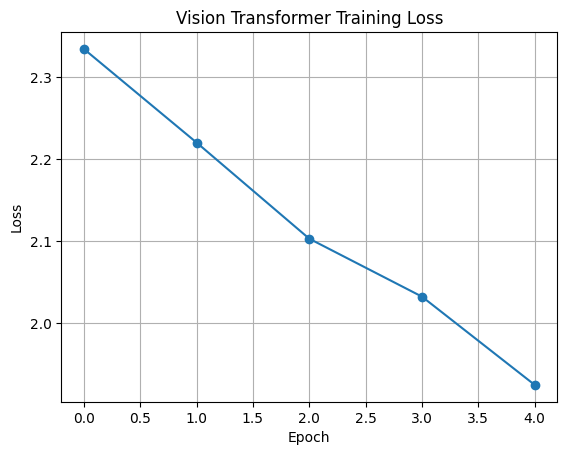

In [28]:
plt.plot(
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title(
    "Vision Transformer Training Loss"
)

plt.grid()

plt.show()

In [29]:
model.eval()

with torch.no_grad():

    logits, attention = model(
        input_image
    )

In [30]:
attention_map = attention[
    0,
    0,
    0,
    1:
]

In [31]:
attention_map = attention_map.reshape(
    14,
    14
)

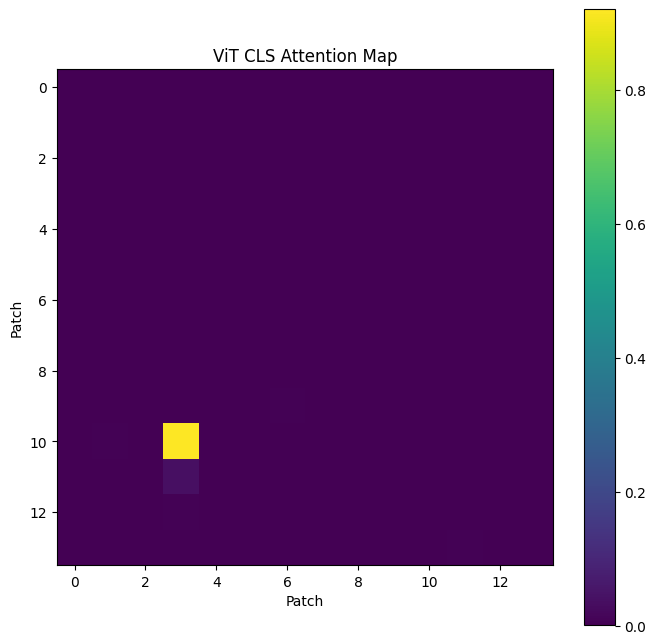

In [32]:
plt.figure(figsize=(8, 8))

plt.imshow(
    attention_map.cpu(),
    cmap="viridis"
)

plt.colorbar()

plt.title(
    "ViT CLS Attention Map"
)

plt.xlabel("Patch")

plt.ylabel("Patch")

plt.show()

In [33]:
import cv2

attention_numpy = (
    attention_map
    .detach()
    .cpu()
    .numpy()
)

attention_resized = cv2.resize(
    attention_numpy,
    (224, 224)
)

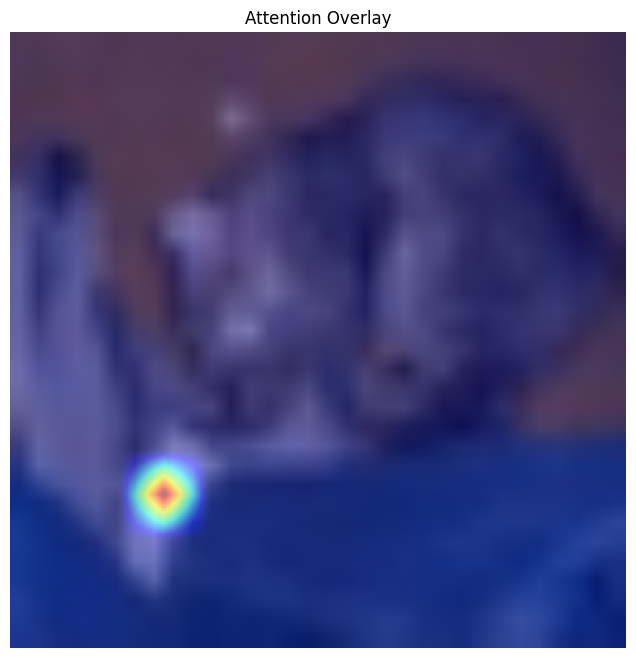

In [34]:
plt.figure(figsize=(8, 8))

plt.imshow(
    image.permute(
        1,
        2,
        0
    )
)

plt.imshow(
    attention_resized,
    cmap="jet",
    alpha=0.5
)

plt.title(
    "Attention Overlay"
)

plt.axis("off")

plt.show()